原始维度: (4592,)
处理后维度 (输入模型用): (4096,)


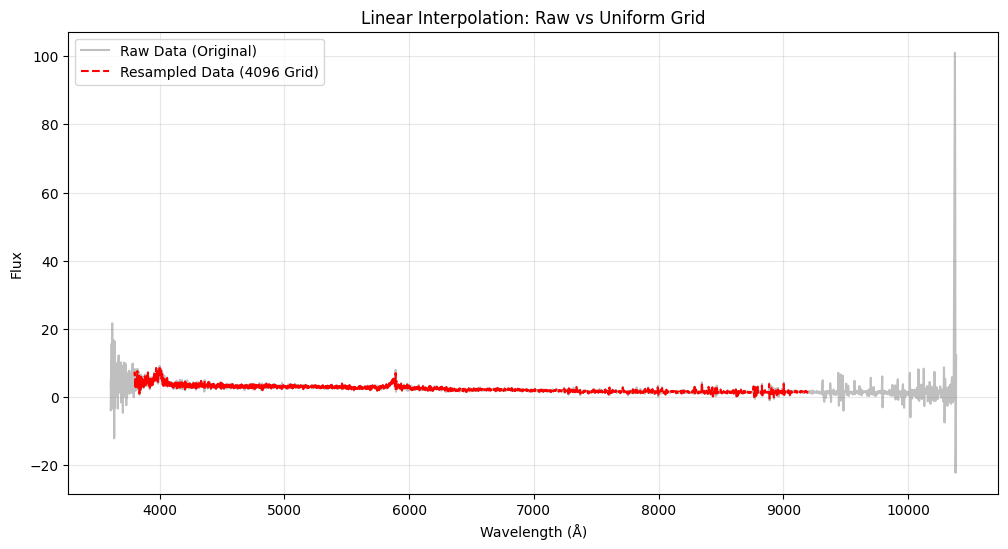

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def preprocess_spectrum_interpolation(raw_wave, raw_flux, raw_ivar,
                                      target_len=4096,
                                      wave_min=3800.0,
                                      wave_max=9200.0):
    """
    对类星体光谱进行线性插值，统一到对数网格上。

    参数:
        raw_wave: 原始波长数组 (Å)
        raw_flux: 原始流量数组
        raw_ivar: 原始逆方差数组 (权重)
        target_len: 目标网格长度 (默认 4096)
        wave_min/max: 目标波长范围

    返回:
        grid_flux: 插值后的流量
        grid_ivar: 插值后的权重 (用于生成Mask)
        grid_wave: 对应的波长网格 (供参考)
    """

    # ---------------------------------------------------------
    # 第一步：构建统一的“对数波长网格” (The Uniform Grid)
    # ---------------------------------------------------------
    # 我们在 log10 空间均匀取点，这是天文学的标准做法
    log_start = np.log10(wave_min)
    log_end = np.log10(wave_max)

    # 生成 log_wave 网格
    grid_log_wave = np.linspace(log_start, log_end, target_len)

    # 转换回物理波长 (Å)，这就是我们的“标准尺子” x 坐标
    grid_wave = 10**grid_log_wave

    # ---------------------------------------------------------
    # 第二步：线性插值 (Linear Interpolation) - 核心操作
    # ---------------------------------------------------------
    # np.interp(x_new, x_old, y_old, left=0, right=0)
    # left=0, right=0 的意思是：如果标准尺子超出了原始数据的范围，
    # (比如原始数据只到 9000Å，但我们要 9200Å)，超出部分自动填 0。

    # 1. 插值 Flux
    # 这里的原理是：在 raw_wave 中找到 grid_wave 对应的位置，连接两点画直线找值
    grid_flux = np.interp(grid_wave, raw_wave, raw_flux, left=0.0, right=0.0)

    # 2. 插值 Ivar (处理权重)
    # 对 ivar 做线性插值是可以接受的近似。
    # 比如 左边ivar=1(好点), 右边ivar=0(坏点), 中间插值出来是 0.5 (半好半坏),
    # 这在深度学习中代表权重降低，逻辑是通的。
    grid_ivar = np.interp(grid_wave, raw_wave, raw_ivar, left=0.0, right=0.0)

    # ---------------------------------------------------------
    # 第三步：后处理 (清洗插值产生的微小负值或异常)
    # ---------------------------------------------------------
    # 确保 ivar 不会出现奇怪的负值 (虽然理论上不会，但为了安全)
    grid_ivar[grid_ivar < 0] = 0

    # 如果原始 ivar=0 的地方是大段缺失，线性插值可能会在坏点之间连线
    # 简单的做法是：如果插值后的 ivar 太小，我们认为这里依然不可信
    # (可选操作：根据具体需求决定是否开启)
    # threshold = 1e-4
    # grid_flux[grid_ivar < threshold] = 0

    return grid_flux, grid_ivar, grid_wave

# ==========================================
# 模拟运行演示
# ==========================================

# 1. 制造一些假数据 (模拟一个 SDSS fits 文件读取出的内容)
# 假设原始数据长度不一 (比如 4500)，范围也不完全对齐
# old_len = 4500
# raw_wave = np.linspace(3700, 9100, old_len) # 注意：它没覆盖到 9200
# raw_flux = np.sin(raw_wave / 1000) * 10 + np.random.normal(0, 1, old_len) # 模拟信号+噪声
# raw_ivar = np.ones(old_len)
#
# # 模拟一个坏点区域 (ivar=0)
# raw_ivar[2000:2050] = 0 # 中间有一段坏了
# raw_flux[2000:2050] = 0 # 坏掉的地方 flux 也是乱的

from astropy.io import fits
from astropy.table import Table
import pandas as pd

# 1. 读取 FITS 文件
hdul = fits.open('spect/spec-6782-56602-0586.fits')
data = hdul[1].data
raw_wave=10**data['loglam']
raw_flux=data['flux']
raw_ivar=data['ivar']

# 2. 调用函数进行处理
new_flux, new_ivar, new_wave = preprocess_spectrum_interpolation(
    raw_wave, raw_flux, raw_ivar, target_len=4096
)

# 3. 打印维度检查
print(f"原始维度: {raw_wave.shape}")
print(f"处理后维度 (输入模型用): {new_flux.shape}")
# 结果应该是 (4096,)

# 4. 可视化对比 (看看发生了什么)
plt.figure(figsize=(12, 6))

# 画原始数据
plt.plot(raw_wave, raw_flux, label='Raw Data (Original)', alpha=0.5, color='gray')

# 画插值后的数据
# 注意看 9100-9200 Å 的部分，因为原始数据没有，所以被自动填 0 了 (Zero Padding)
plt.plot(new_wave, new_flux, label='Resampled Data (4096 Grid)', color='red', linestyle='--')

plt.title("Linear Interpolation: Raw vs Uniform Grid")
plt.xlabel("Wavelength (Å)")
plt.ylabel("Flux")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import argparse
import os

# ==========================================
# 配置参数 (与你的 Pipeline 保持一致)
# ==========================================
TARGET_LEN = 4096
WAVE_START = 3800.0
WAVE_END = 9000.0

def process_and_visualize(fits_path):
    """
    读取 FITS，执行标准的预处理流程，并画图对比
    """
    if not os.path.exists(fits_path):
        print(f"错误: 找不到文件 {fits_path}")
        return

    print(f"正在读取: {os.path.basename(fits_path)}")

    # 1. 读取原始数据
    with fits.open(fits_path) as hdul:
        data = hdul[1].data
        raw_flux = data['flux'].astype(np.float32)
        raw_loglam = data['loglam'].astype(np.float32)
        raw_ivar = data['ivar'].astype(np.float32)

        # 获取一些元数据用于展示
        header = hdul[0].header
        obj_info = f"Plate:{header.get('PLATEID')} MJD:{header.get('MJD')} Fiber:{header.get('FIBERID')}"

    # -------------------------------------------------
    # 模拟 Pipeline 中的处理流程
    # -------------------------------------------------

    # A. 生成目标对数波长网格
    target_log_grid = np.linspace(np.log10(WAVE_START), np.log10(WAVE_END), TARGET_LEN)

    # B. 数据清洗 (关键步骤：处理 ivar)
    # 复制一份用于处理，保留 raw_flux 用于画图对比
    clean_flux = raw_flux.copy()

    # 定义坏点掩膜：ivar <= 0 或者 非数值
    # 某些 SDSS 版本 ivar=0 代表掩膜，极小值代表高噪
    bad_mask = (raw_ivar <= 0) | (~np.isfinite(clean_flux))

    # 将坏点置为 0 (对于神经网络通常这样做，也就是 Masking)
    clean_flux[bad_mask] = 0.0

    # C. 线性插值重采样
    # left=0, right=0 保证了超出 3800-9000 范围的部分被置零（实际上我们只取了范围内的网格）
    resampled_flux = np.interp(target_log_grid, raw_loglam, clean_flux, left=0.0, right=0.0)

    # -------------------------------------------------
    # 可视化部分
    # -------------------------------------------------

    # 转换回线性波长用于绘图 (人类更容易读懂 Angstrom)
    wave_linear_raw = 10 ** raw_loglam
    wave_linear_target = 10 ** target_log_grid

    plt.figure(figsize=(15, 8), dpi=100)

    # 1. 绘制原始光谱 (灰色，半透明)
    plt.plot(wave_linear_raw, raw_flux, color='gray', alpha=0.5, linewidth=1, label='Raw Original (with Noise)')

    # 2. 绘制处理后的光谱 (红色)
    # 注意：为了让图看清楚，我们可能需要限制一下 Y 轴，因为原始数据可能有极大的宇宙射线
    plt.plot(wave_linear_target, resampled_flux, color='red', alpha=0.8, linewidth=1.5, label=f'Processed ({TARGET_LEN} px)')

    # 3. 标记处理范围边界
    plt.axvline(x=WAVE_START, color='blue', linestyle='--', alpha=0.6, label='Cutoff Start (3800A)')
    plt.axvline(x=WAVE_END, color='blue', linestyle='--', alpha=0.6, label='Cutoff End (9000A)')

    # 设置 Y 轴范围：自动忽略极值，聚焦主体
    # 取处理后数据的 1% 和 99% 分位数来定坐标轴，防止宇宙射线把图撑得太扁
    valid_data = resampled_flux[resampled_flux != 0]
    if len(valid_data) > 0:
        y_min, y_max = np.percentile(valid_data, [1, 99])
        margin = (y_max - y_min) * 0.2
        plt.ylim(y_min - margin, y_max + margin)

    plt.title(f"Spectrum Processing Verification\n{obj_info}", fontsize=14)
    plt.xlabel("Wavelength (Angstrom)", fontsize=12)
    plt.ylabel("Flux (10^-17 erg/s/cm^2/A)", fontsize=12)
    plt.legend(loc='upper right', frameon=True)
    plt.grid(True, which='both', linestyle='--', alpha=0.5)

    # 添加文字说明分辨率
    raw_res = (raw_loglam[-1] - raw_loglam[0]) / len(raw_loglam)
    target_res = (target_log_grid[-1] - target_log_grid[0]) / len(target_log_grid)
    info_text = (
        f"Original Sampling: ~{raw_res:.6f} log(A)/pix\n"
        f"Target Sampling:   ~{target_res:.6f} log(A)/pix\n"
        f"Status: {'Oversampling (Good)' if target_res < raw_res else 'Undersampling'}"
    )
    plt.text(0.02, 0.95, info_text, transform=plt.gca().transAxes,
             fontsize=11, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    output_filename = f"./spect/png/{os.path.basename(fits_path)}.png"
    plt.savefig(output_filename)
    print(f"可视化结果已保存至: {output_filename}")
    # 如果在本地运行，可以取消注释下面这行
    plt.show()

# if __name__ == "__main__":
#     fits_file="./spect/spec-6782-56602-0586.fits"
#
#     process_and_visualize(fits_file)

正在读取: spec-10238-58155-0018.fits
可视化结果已保存至: ./spect/png/spec-10238-58155-0018.fits.png


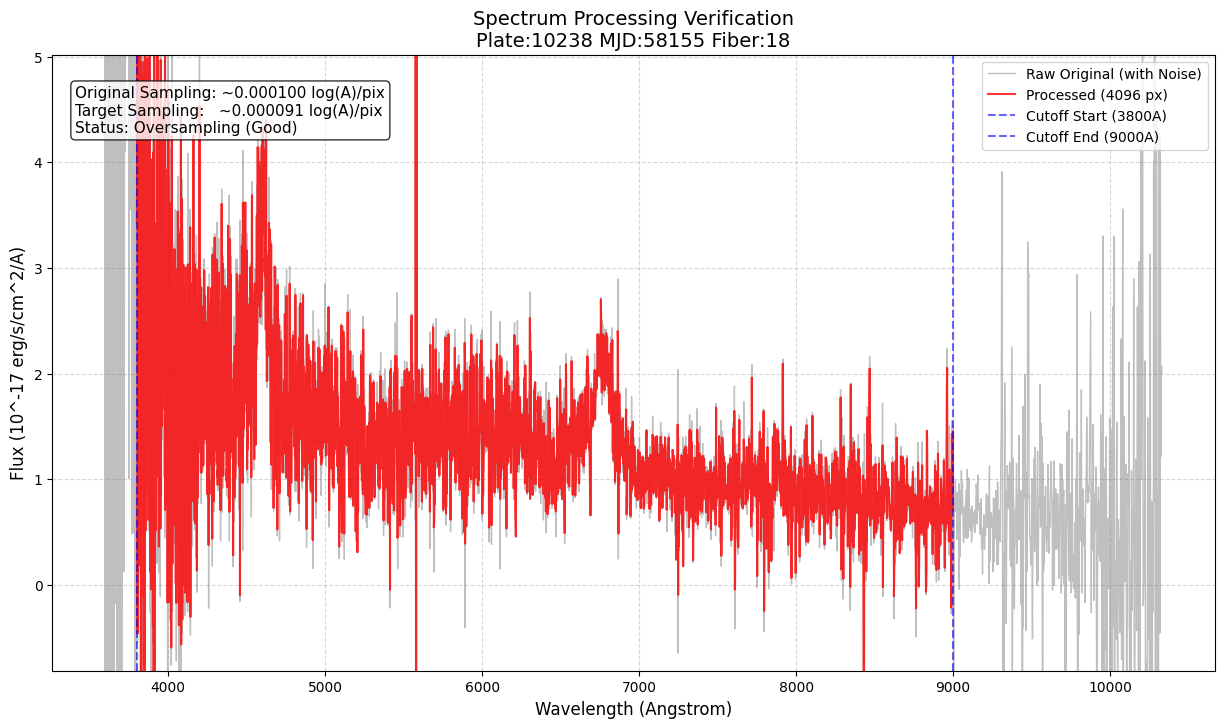

正在读取: spec-4854-55685-0148.fits
可视化结果已保存至: ./spect/png/spec-4854-55685-0148.fits.png


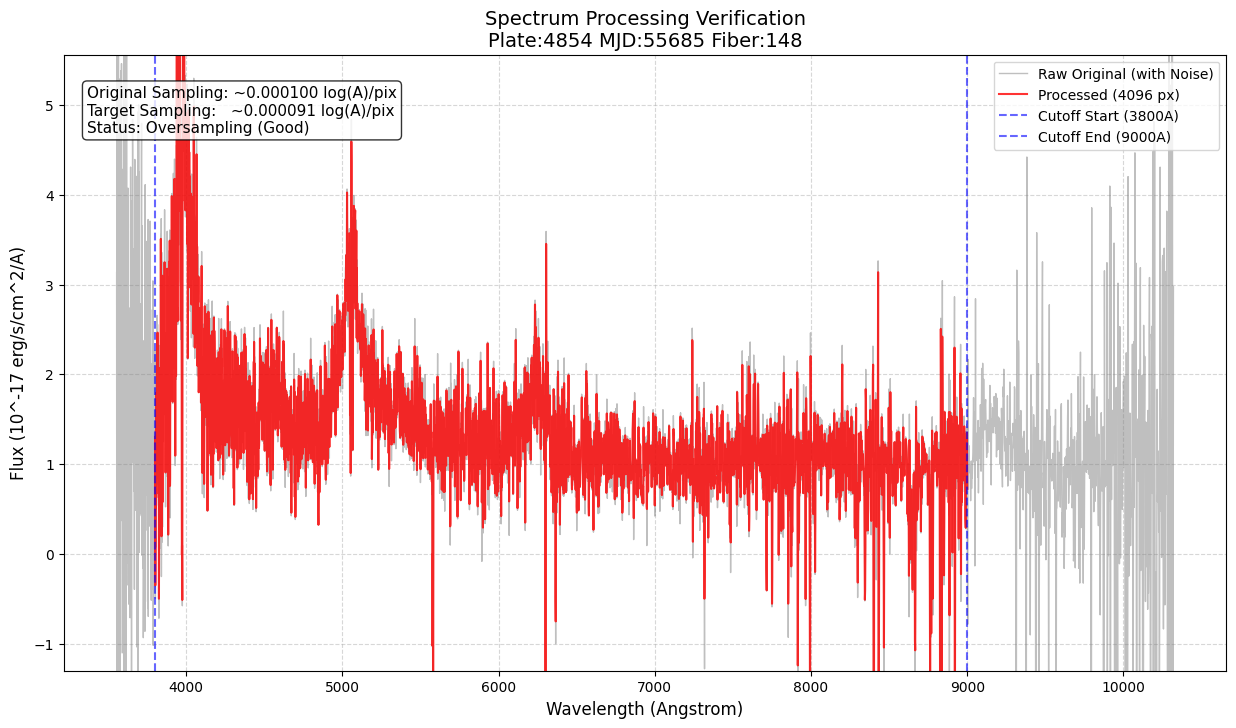

正在读取: spec-5172-56071-0878.fits
可视化结果已保存至: ./spect/png/spec-5172-56071-0878.fits.png


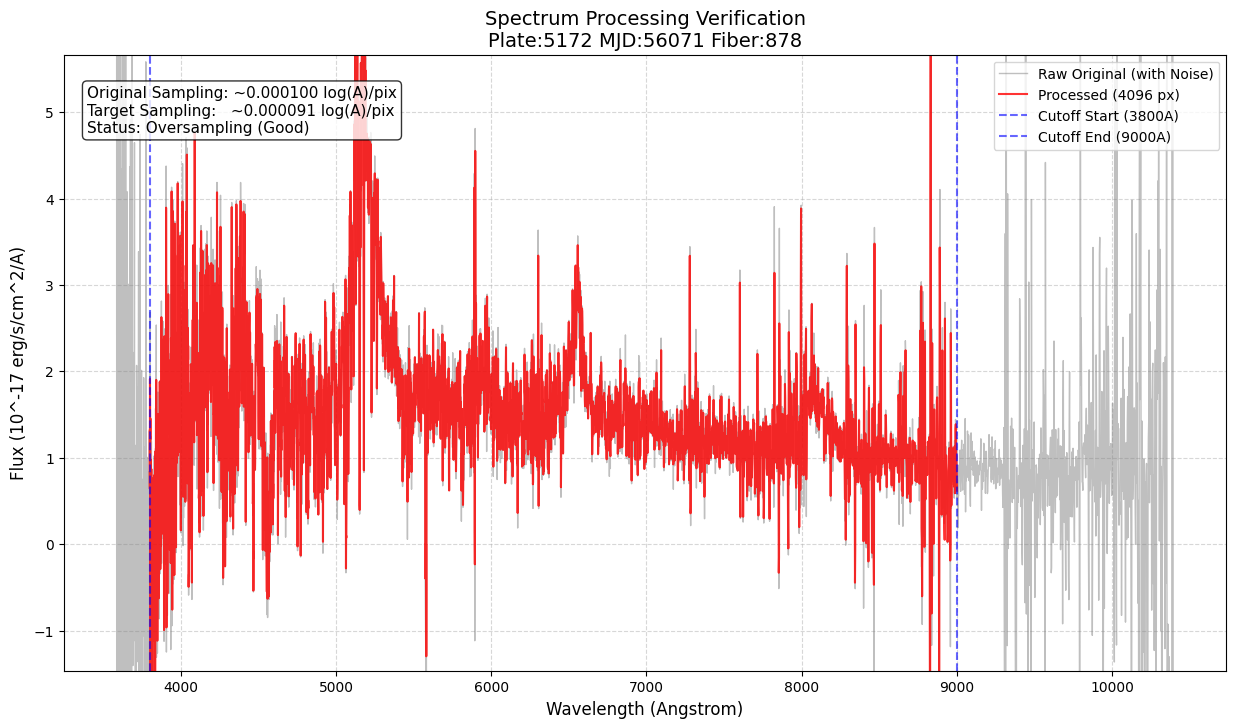

正在读取: spec-5809-56353-0798.fits
可视化结果已保存至: ./spect/png/spec-5809-56353-0798.fits.png


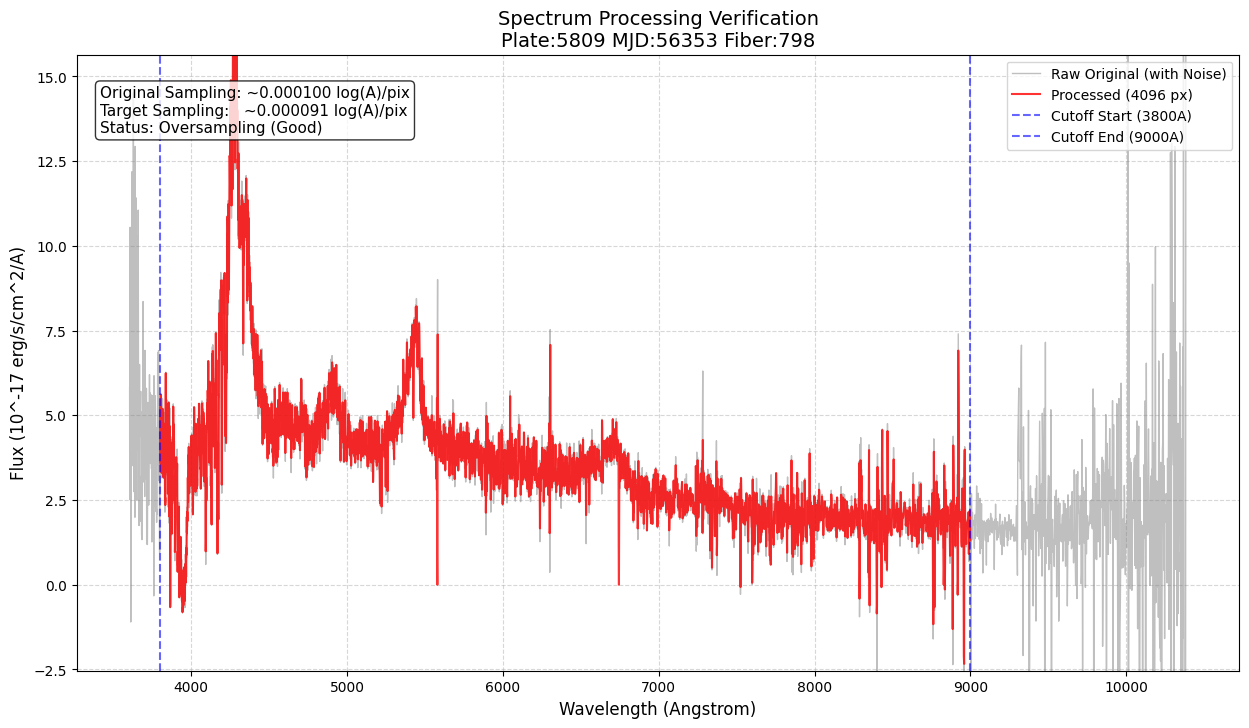

正在读取: spec-5946-56101-0267.fits
可视化结果已保存至: ./spect/png/spec-5946-56101-0267.fits.png


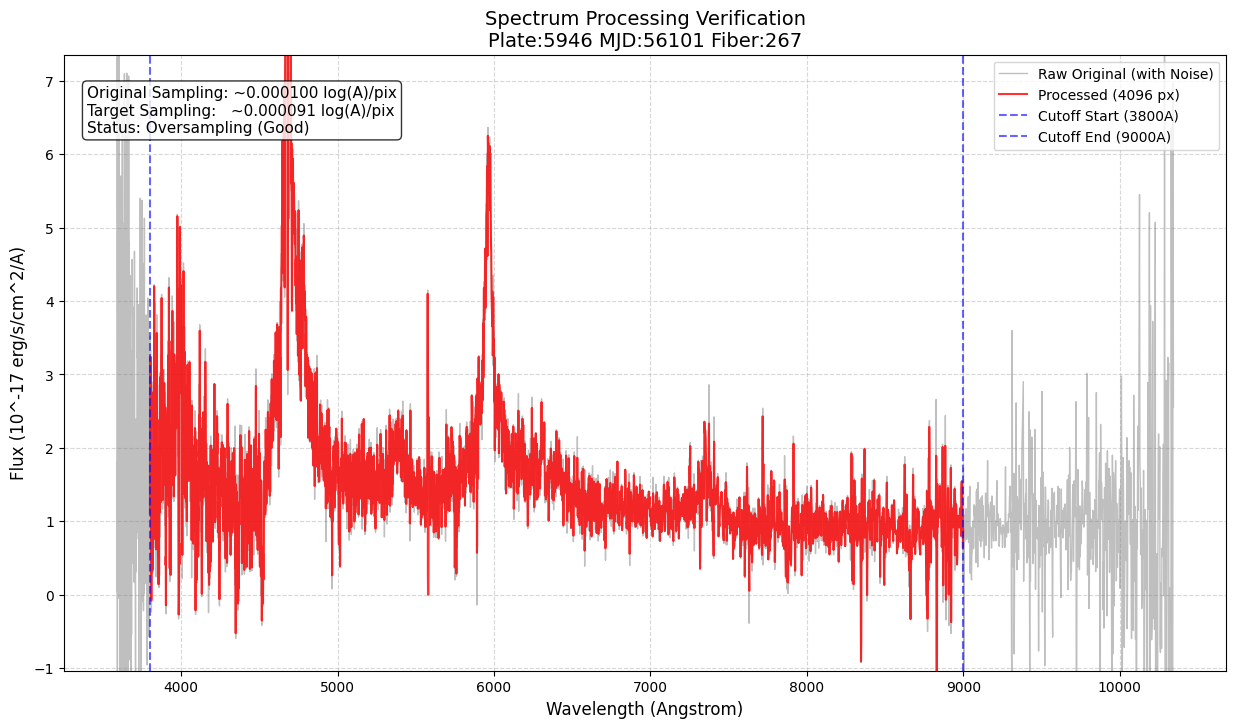

正在读取: spec-5992-56066-0822.fits
可视化结果已保存至: ./spect/png/spec-5992-56066-0822.fits.png


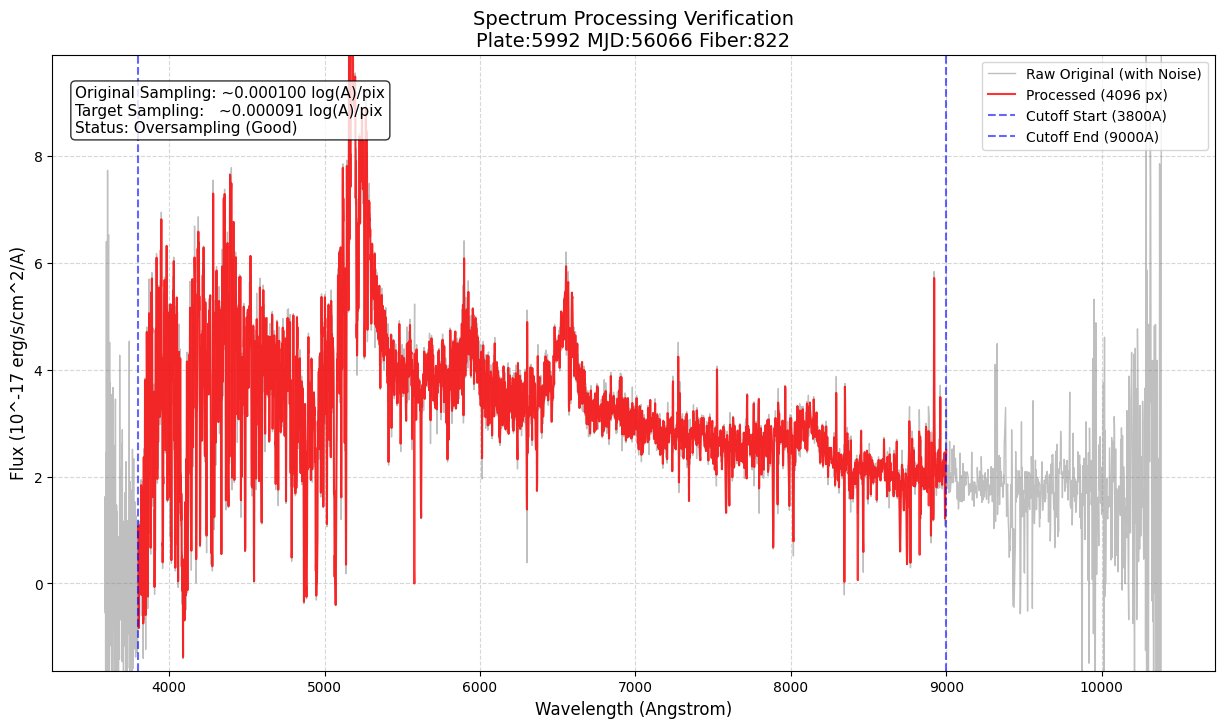

正在读取: spec-6693-56384-0458.fits
可视化结果已保存至: ./spect/png/spec-6693-56384-0458.fits.png


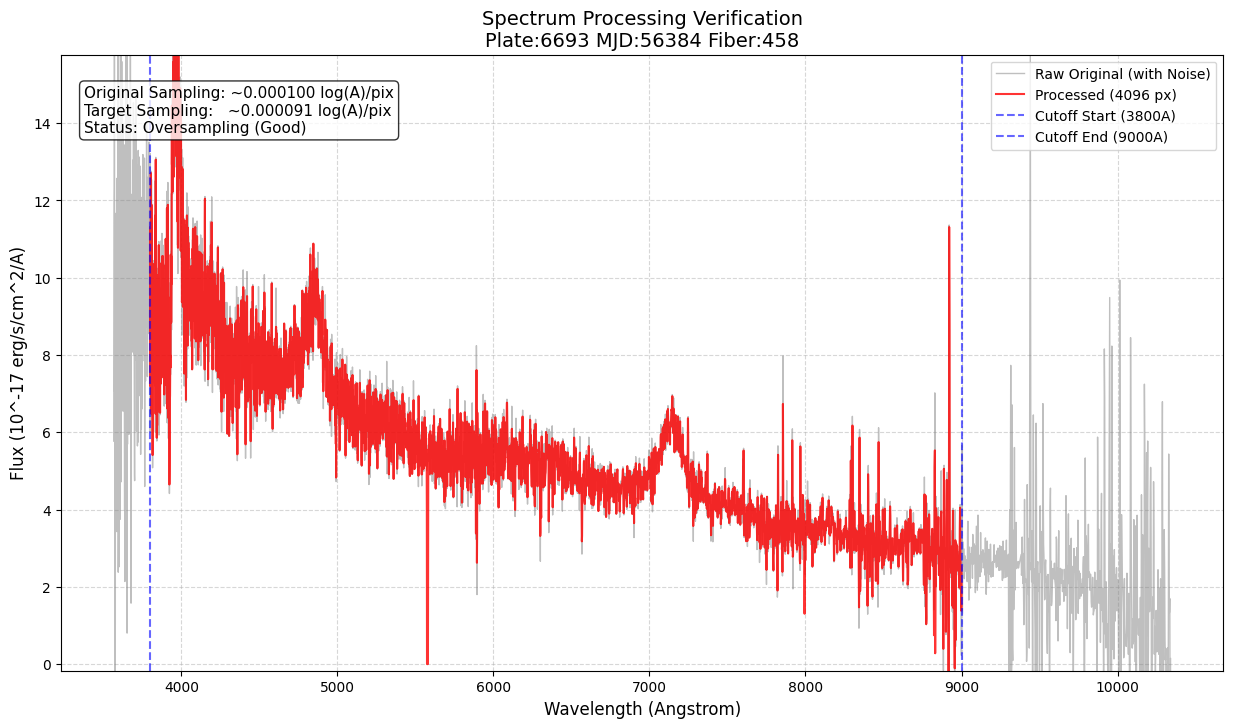

正在读取: spec-6782-56572-0285.fits
可视化结果已保存至: ./spect/png/spec-6782-56572-0285.fits.png


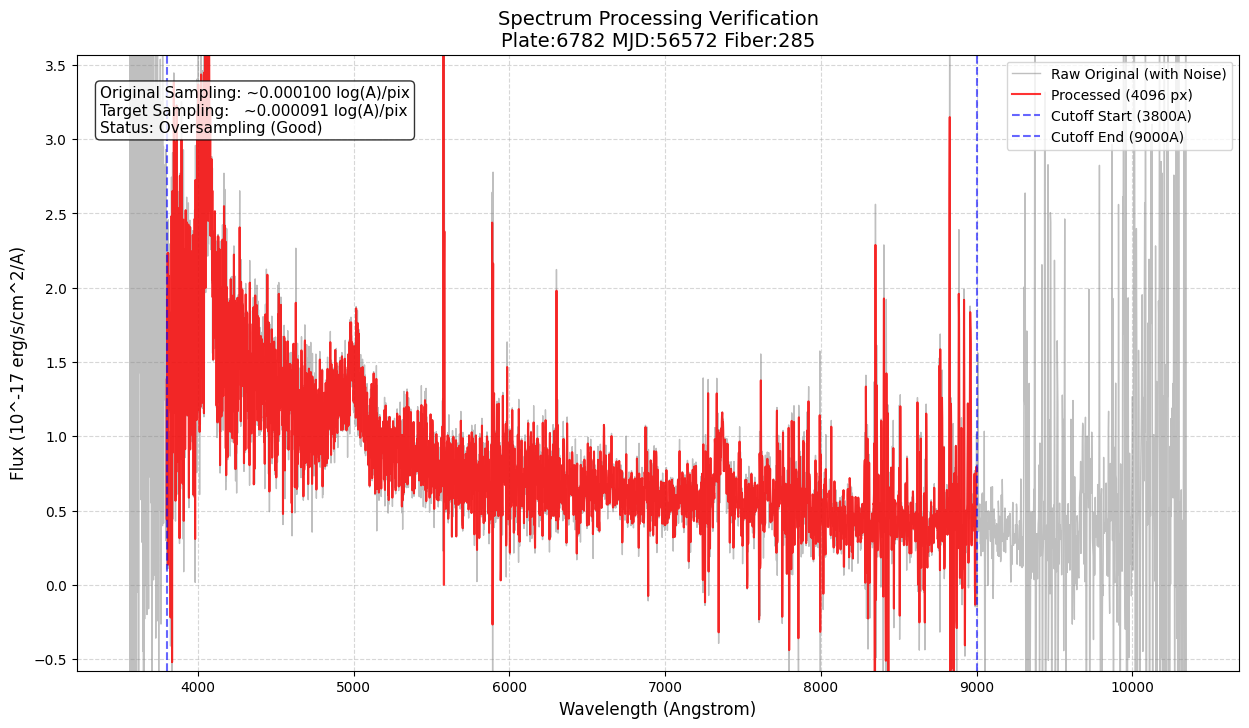

正在读取: spec-8742-57364-0846.fits
可视化结果已保存至: ./spect/png/spec-8742-57364-0846.fits.png


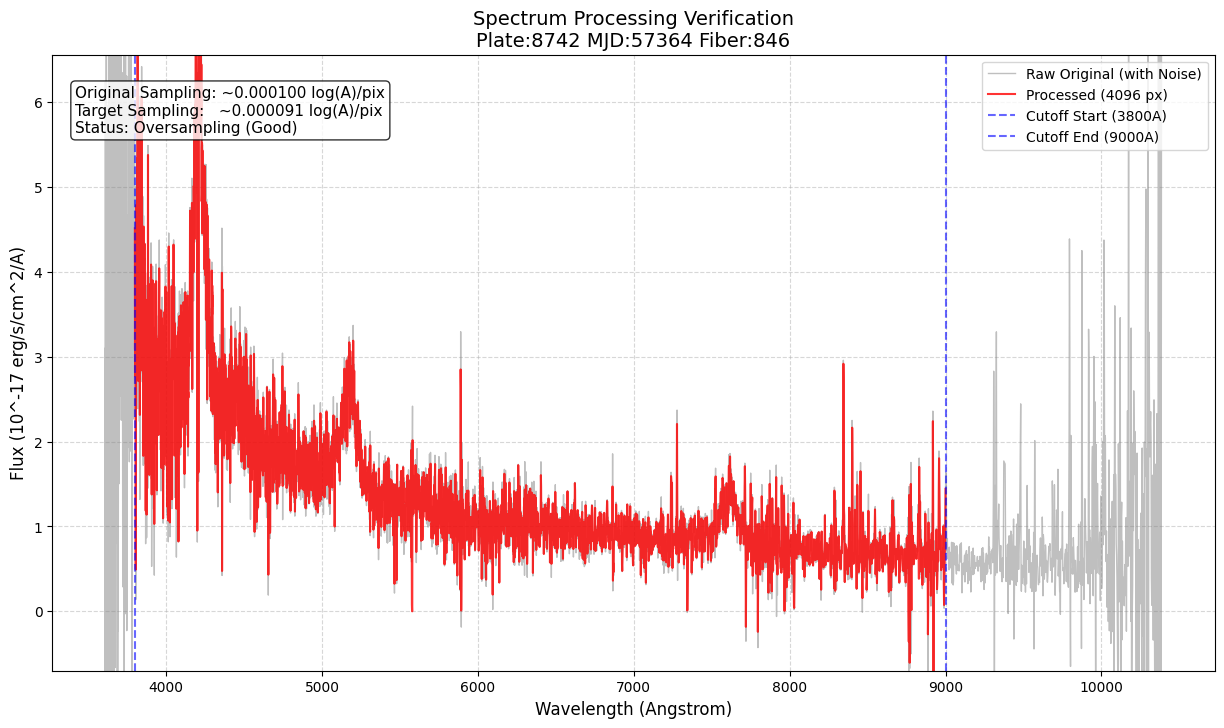

正在读取: spec-8744-58124-0745.fits
可视化结果已保存至: ./spect/png/spec-8744-58124-0745.fits.png


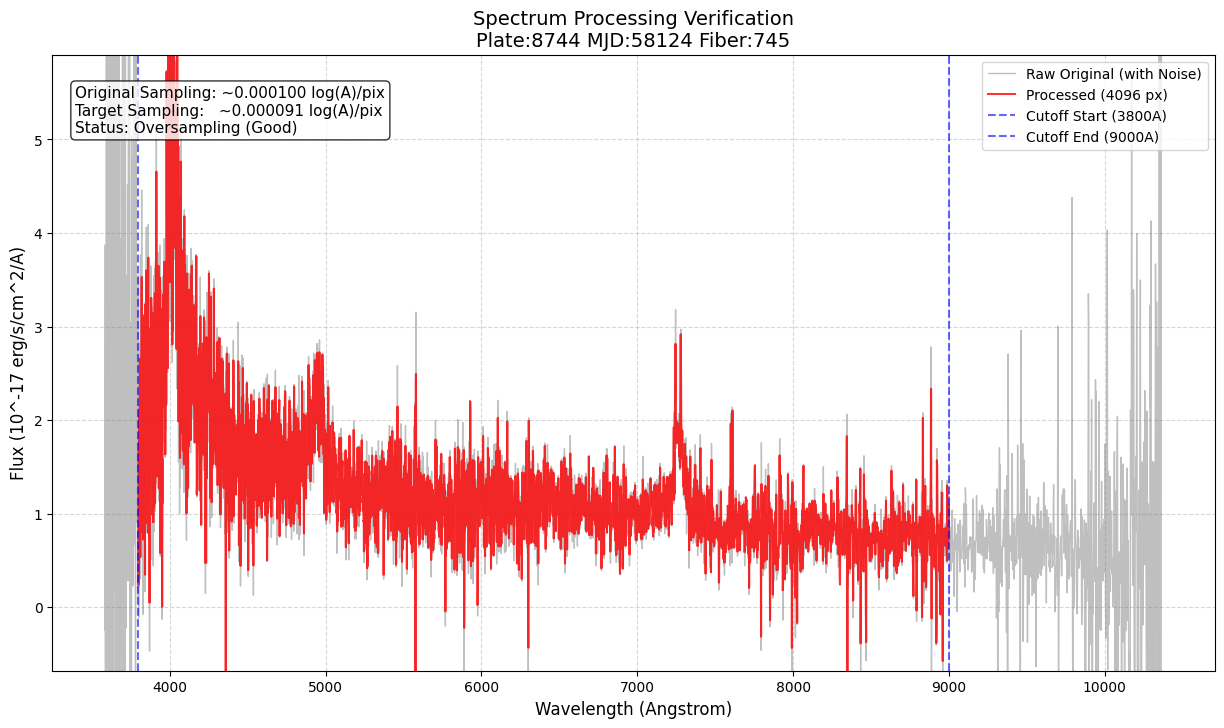

In [15]:
fits_file= "../spect"
#获取该目录下所有文件路径
file_paths = [os.path.join(fits_file, f) for f in os.listdir(fits_file) if os.path.isfile(os.path.join(fits_file, f))]
for f in file_paths:
    process_and_visualize(f)

In [11]:
fits_file= "../spect"
#获取该目录下所有文件路径
file_paths = [os.path.join(fits_file, f) for f in os.listdir(fits_file) if os.path.isfile(os.path.join(fits_file, f))]
print(file_paths)

['./spect/spec-10238-58155-0018.fits', './spect/spec-4854-55685-0148.fits', './spect/spec-5172-56071-0878.fits', './spect/spec-5809-56353-0798.fits', './spect/spec-5946-56101-0267.fits', './spect/spec-5992-56066-0822.fits', './spect/spec-6693-56384-0458.fits', './spect/spec-6782-56572-0285.fits', './spect/spec-8742-57364-0846.fits', './spect/spec-8744-58124-0745.fits']
